In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f"x_train shape: {x_train.shape}")
x_train, x_test = x_train / 255.0, x_test / 255.0  # Normalize
#x_train = x_train[..., np.newaxis]  # Add channel dimension
#x_test = x_test[..., np.newaxis]

x_train = x_train.reshape(-1, 28, 28, 1)  # Add channel dimension
print(f"x_train shape: {x_train.shape}")
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = to_categorical(y_train, num_classes=10)  # Convert to one-hot
y_test = to_categorical(y_test, num_classes=10)

# Define a simple neural network
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='sigmoid', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), strides=(2, 2), activation='sigmoid'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model on MNIST
model.fit(x_train, y_train, epochs=3, batch_size=64, validation_data=(x_test, y_test))

print("Model training complete!")


x_train shape: (60000, 28, 28)
x_train shape: (60000, 28, 28, 1)


W0000 00:00:1740220452.358649    9480 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.3713 - loss: 1.7708 - val_accuracy: 0.9117 - val_loss: 0.3194
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9188 - loss: 0.2834 - val_accuracy: 0.9482 - val_loss: 0.1779
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9456 - loss: 0.1778 - val_accuracy: 0.9580 - val_loss: 0.1355
Model training complete!


In [4]:
y_pred_probs = model.predict(x_test)  # Softmax probabilities
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
y_test = np.argmax(y_test, axis=1)  # Convert ground truth to class labels

# ✅ 6. Ensure Data Type Matches
y_test = tf.convert_to_tensor(y_test, dtype=tf.int32)
y_pred = tf.convert_to_tensor(y_pred, dtype=tf.int32)

# ✅ 7. Compute Precision & Recall
precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()

precision.update_state(y_test, y_pred)
recall.update_state(y_test, y_pred)

print(f"Precision: {precision.result().numpy():.4f}")
print(f"Recall: {recall.result().numpy():.4f}")

# 6. Get Detailed Report (Optional)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Precision: 0.9977
Recall: 0.9973

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.95      0.97      0.96      1032
           3       0.93      0.96      0.95      1010
           4       0.98      0.94      0.96       982
           5       0.97      0.95      0.96       892
           6       0.97      0.98      0.97       958
           7       0.97      0.95      0.96      1028
           8       0.96      0.90      0.93       974
           9       0.90      0.96      0.92      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



Gradients extracted!


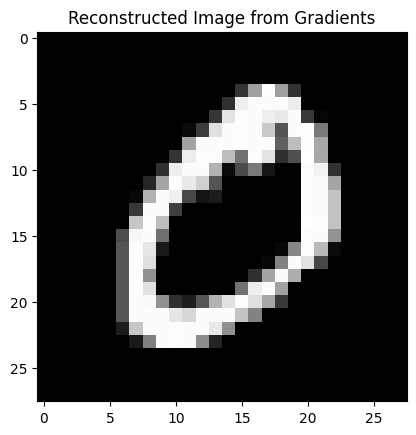

In [11]:
# Function to compute gradients for a single sample
def get_gradients(model, x, y):
    loss_object = tf.keras.losses.CategoricalCrossentropy()
    with tf.GradientTape() as tape:
        #tape.watch(model.trainable_variables)  # Track model weights
        predictions = model(x, training=True)
        loss = loss_object(y, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    return gradients

# Select one sample
x_sample, y_sample = x_train[1:2], y_train[1:2]

# Get gradients
gradients = get_gradients(model, x_sample, y_sample)
print("Gradients extracted!")
plt.imshow(x_sample.squeeze(), cmap="gray")
plt.title("Reconstructed Image from Gradients")
plt.show()

In [12]:
# Simulated leaked gradients (for attack scenario)
#original_dy_dx = [tf.random.normal(w.shape) for w in gradients]  # Simulated leaked gradients
original_dy_dx = [g.numpy() for g in gradients]  # Simulated leaked gradients
#print(original_dy_dx)
# Initialize dummy data & label (random noise)
dummy_data = tf.Variable(tf.random.normal((1, 28, 28, 1)), trainable=True)
dummy_label = tf.Variable(tf.random.normal((1, 10)), trainable=True)
# Custom optimizer similar to LBFGS
optimizer = tf.keras.optimizers.Adam(learning_rate=0.5)  # LBFGS is unavailable, so we use Adam
loss_object = tf.keras.losses.CategoricalCrossentropy()

history = []

# Gradient Inversion Attack Loop
for iters in range(2000):
    with tf.GradientTape(persistent=True) as tape:  # Enable persistent to allow second-order gradients
        pred = model(dummy_data)  
        dummy_onehot_label = tf.nn.softmax(dummy_label, axis=-1)  # Convert label to one-hot
        dummy_loss = loss_object(dummy_onehot_label, pred)  

        # Compute gradients of the dummy loss w.r.t. model parameters
        dummy_dy_dx = tape.gradient(dummy_loss, model.trainable_variables)

        # Compute gradient difference loss
        grad_diff = tf.add_n([tf.reduce_sum(tf.square(gx - gy)) for gx, gy in zip(dummy_dy_dx, original_dy_dx)])
        #grad_diff = tf.add_n([tf.norm(gx - gy, ord='euclidean')**2 for gx, gy in zip(dummy_dy_dx, original_dy_dx)])

    # Compute gradients for dummy_data and dummy_label
    dummy_grads = tape.gradient(grad_diff, [dummy_data, dummy_label])  # FIXED: Now works correctly

    # Apply gradients (update dummy input)
    optimizer.apply_gradients(zip(dummy_grads, [dummy_data, dummy_label]))

    if iters % 500 == 0:
        print(f"Iteration {iters}, Loss: {grad_diff.numpy():.4f}")

    history.append(dummy_data.numpy()[0])

Iteration 0, Loss: 105.9527
Iteration 500, Loss: 7.4624
Iteration 1000, Loss: 7.2180
Iteration 1500, Loss: 7.1270


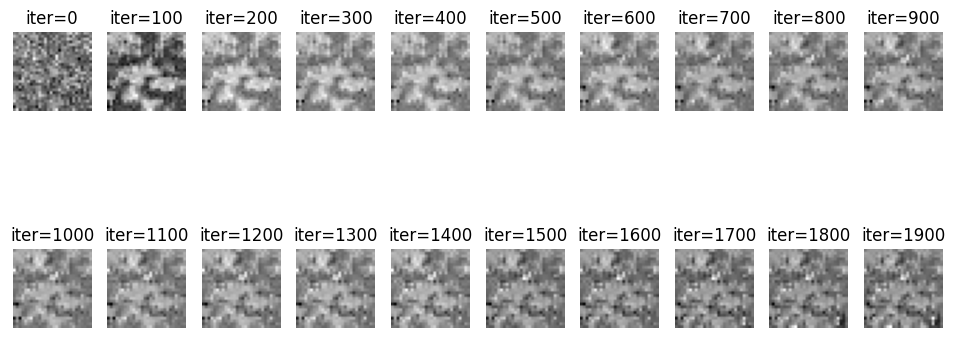

In [9]:
plt.figure(figsize=(12, 8))
for i in range(20):
  plt.subplot(3, 10, i + 1)
  plt.imshow(history[i * 100], cmap="gray")
  plt.title("iter=%d" % (i * 100))
  plt.axis('off')

In [16]:
import tensorflow as tf
import numpy as np

# Original input data (secret data)
true_input = tf.Variable([[3.0, 4.0]], dtype=tf.float32)  # The input we want to recover
true_label = tf.constant([[1.0]], dtype=tf.float32)  # True label

# Define a simple model (1-layer)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(2,), use_bias=False)  # No bias to simplify gradients
])

# Compute original gradients (simulating what a client would send in FL)
with tf.GradientTape() as tape:
    prediction = model(true_input)
    loss = tf.reduce_mean(tf.square(prediction - true_label))  # MSE loss

# Get the gradients of the loss w.r.t. model weights
original_gradients = tape.gradient(loss, model.trainable_variables)[0]  # Gradient w.r.t weights

print(f"Leaked Gradient: \n{original_gradients.numpy()}")

# --- Gradient Inversion: Reconstruct Input from Gradients ---

# Create a dummy input to optimize (starting with random values)
reconstructed_input = tf.Variable(tf.random.normal((1, 2)), dtype=tf.float32)

# Optimizer to reconstruct the input
optimizer = tf.optimizers.Adam(learning_rate=0.1)

# Reconstruction loop
for i in range(300):  # Iterate to minimize error
    with tf.GradientTape(persistent=True) as recon_tape:
        # Compute gradient of dummy input
        recon_prediction = model(reconstructed_input)
        recon_loss = tf.reduce_mean(tf.square(recon_prediction - true_label))  # Same loss
        reconstructed_grad = recon_tape.gradient(recon_loss, model.trainable_variables)[0]
        
        # Loss function: Minimize the difference between original and reconstructed gradient
        gradient_loss = tf.reduce_mean(tf.square(reconstructed_grad - original_gradients))

    # Compute gradients and apply them
    grads = recon_tape.gradient(gradient_loss, [reconstructed_input])
    optimizer.apply_gradients(zip(grads, [reconstructed_input]))

    if i % 50 == 0:
        print(f"Step {i}: Gradient Loss = {gradient_loss.numpy()}")

# Final reconstructed input
print(f"\nOriginal Input: {true_input.numpy()}")
print(f"Reconstructed Input: {reconstructed_input.numpy()}")


Leaked Gradient: 
[[ 7.652933]
 [10.203911]]


/home/alex/dev/he-fl-root/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 0: Gradient Loss = 94.481201171875
Step 50: Gradient Loss = 2.6475958824157715
Step 100: Gradient Loss = 0.005171760451048613
Step 150: Gradient Loss = 4.964049821865046e-06
Step 200: Gradient Loss = 6.651862349826843e-08
Step 250: Gradient Loss = 1.1652900866465643e-10

Original Input: [[3. 4.]]
Reconstructed Input: [[3.       3.999998]]
